# Task 2

In [14]:
# # clear unneeded folders
# classes = None
# with open("data/food-101/meta/classes.txt") as f:
#     classes = f.readlines()
# classes = [c.strip("\n") for c in classes]
# print(len(classes))
# classes.remove("hot_and_sour_soup")
# classes.remove("pork_chop")
# classes.remove("beef_tartare")
# classes.remove("crab_cakes")
# classes.remove("baby_back_ribs")
# classes.remove("guacamole")
# classes.remove("french_onion_soup")
# classes.remove("dumplings")
# classes.remove("sushi")
# classes.remove("cheesecake")
# print(len(classes))

# import os
# import shutil

# current_dir = os.getcwd()
# images_dir = os.path.join(current_dir, "data/Food10")
# for c in classes:
#     to_rm = os.path.join(images_dir, c)
#     shutil.rmtree(to_rm)


In [15]:
# import os
# import shutil
# current_dir = os.getcwd()
# train_dir = os.path.join(current_dir, "Food10")
# test_dir = os.path.join(current_dir, "FoodTest")

# # Separate train and test data
# with open("test.csv") as f:
#     test_images = f.readlines()[1:]
# test_images = [ti.strip("\n").split(",")[1].split("\\") for ti in test_images]
# test_images = ["/".join(ti[-2:]) for ti in test_images]

# for im in test_images:
#     shutil.move(os.path.join(train_dir, im), os.path.join(test_dir, im))

# # Food10 for training, FoodTest for testing

In [16]:
import matplotlib.pyplot as plt 
import numpy as np 
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential 


In [17]:
import os
current_dir = os.getcwd()
train_dir = os.path.join(current_dir, "Food10")
test_dir = os.path.join(current_dir, "FoodTest")

# train = tf.keras.utils.image_dataset_from_directory( 
# 	train_dir, 
#     validation_split=0.3, 
# 	subset="training", 
# 	seed=55,
# 	image_size=(224, 224), 
# 	batch_size=32) 

# test = tf.keras.utils.image_dataset_from_directory( 
# 	train_dir, 
#     validation_split=0.2, 
# 	subset="validation", 
# 	seed=55,
# 	image_size=(224, 224), 
# 	batch_size=32) 

# class_names = train.class_names 
# print(class_names)

In [18]:
# losses = [tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#           tf.keras.losses.CategoricalCrossentropy(from_logits=True),
#           tf.keras.losses.CategoricalFocalCrossentropy(from_logits=True)]
# epoch_nums = [10, 50, 100]

# best_model = None
# best_test_accuracy = 0.0
# best_loss = None
# best_epochs = None

# try:
#     for loss in losses:
#         for epochs in epoch_nums:
#             model = Sequential([ 
#                 layers.Rescaling(1./255, input_shape=(224,224, 3)), 
#                 layers.Conv2D(16, 3, padding='same', activation='relu'), 
#                 layers.MaxPooling2D(), 
#                 layers.Conv2D(32, 3, padding='same', activation='relu'), 
#                 layers.MaxPooling2D(), 
#                 layers.Conv2D(64, 3, padding='same', activation='relu'), 
#                 layers.MaxPooling2D(), 
#                 layers.Flatten(), 
#                 layers.Dense(128, activation='relu'), 
#                 layers.Dense(10) 
#             ]) 
#             model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
#             history = model.fit(train, validation_data=test, epochs=epochs)
#             test_acc = history.history['val_accuracy'] 
#             print(test_acc)
#             if test_acc[-1] > best_test_accuracy:
#                 best_model = model
#                 best_test_accuracy = test_acc[-1]
#                 best_loss = loss
#                 best_epochs = epochs
# except KeyboardInterrupt:
#     pass
# finally:
#     print(f"Best validation accuracy achieved: {best_test_accuracy}")
#     # Dump best model just in case of accidental loss
#     import pickle
#     try:
#         with open ("best_model", "w") as f:
#             pickle.dump((best_model, best_loss, best_epochs), f)
#     except:
#         print("ERROR IN DUMPING")
#         with open("best_model", "w") as f:
#             pickle.dump(best_model, f)

In [19]:
def make_model():
    inputs = keras.Input(shape=(224,224, 3))

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.RandomFlip("horizontal")(x) # Helps introduce variety to expand dataset & reduce overfitting
    x = layers.RandomRotation(0.1)(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = layers.Dense(10, activation=None)(x)
    return keras.Model(inputs, outputs)



In [20]:
# model = make_model()
# model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
# history = model.fit(train, validation_data=test, epochs=60)


In [21]:

# acc = history.history['accuracy'] 
# val_acc = history.history['val_accuracy'] 
# loss = history.history['loss'] 
# val_loss = history.history['val_loss'] 
# epochs_range = range(60) 
# plt.figure(figsize=(8, 8)) 
# plt.subplot(1, 2, 1) 
# plt.plot(epochs_range, acc, label='Training Accuracy') 
# plt.plot(epochs_range, val_acc, label='Validation Accuracy') 
# plt.legend(loc='lower right') 
# plt.title('Training and Validation Accuracy for Sparse Categorical Crossentropy') 
# plt.subplot(1, 2, 2) 
# plt.plot(epochs_range, loss, label='Training Loss') 
# plt.plot(epochs_range, val_loss, label='Validation Loss') 
# plt.legend(loc='upper right') 
# plt.title('Training and Validation Loss') 
# plt.show() 

In [22]:
# model = make_model()
# model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
# history = model.fit(train, validation_data=test, epochs=50)

In [23]:
# acc = history.history['accuracy'] 
# val_acc = history.history['val_accuracy'] 
# loss = history.history['loss'] 
# val_loss = history.history['val_loss'] 
# epochs_range = range(100) 
# plt.figure(figsize=(8, 8)) 
# plt.subplot(1, 2, 1) 
# plt.plot(epochs_range, acc, label='Training Accuracy') 
# plt.plot(epochs_range, val_acc, label='Validation Accuracy') 
# plt.legend(loc='lower right') 
# plt.title('Training and Validation Accuracy for Categorical Crossentropy') 
# plt.subplot(1, 2, 2) 
# plt.plot(epochs_range, loss, label='Training Loss') 
# plt.plot(epochs_range, val_loss, label='Validation Loss') 
# plt.legend(loc='upper right') 
# plt.title('Training and Validation Loss') 
# plt.show() 

In [24]:
train = tf.keras.utils.image_dataset_from_directory( 
	train_dir, 
    validation_split=0.3, 
	subset="training", 
	seed=55,
	image_size=(224, 224), 
	batch_size=32,
    label_mode='categorical') 

test = tf.keras.utils.image_dataset_from_directory( 
	train_dir, 
    validation_split=0.2, 
	subset="validation", 
	seed=55,
	image_size=(224, 224), 
	batch_size=32,
    label_mode='categorical') 

Found 7500 files belonging to 10 classes.
Using 5250 files for training.
Found 7500 files belonging to 10 classes.
Using 1500 files for validation.


In [25]:
model = make_model()
model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalFocalCrossentropy(from_logits=True), metrics=['accuracy'])
history = model.fit(train, validation_data=test, epochs=50)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2347 - loss: 0.4398

E0000 00:00:1774356476.902193   18251 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/functional_1_1/add_5_1/Add' exist for missing node 'StatefulPartitionedCall/functional_1_1/add_4_1/Add'.


165/165 ━━━━━━━━━━━━━━━━━━━━ 572s 3s/step - accuracy: 0.2796 - loss: 0.4041 - val_accuracy: 0.1107 - val_loss: 0.5057
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 555s 3s/step - accuracy: 0.3838 - loss: 0.3206 - val_accuracy: 0.1107 - val_loss: 0.5854
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.4537 - loss: 0.2749 - val_accuracy: 0.1520 - val_loss: 0.6423
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 543s 3s/step - accuracy: 0.5013 - loss: 0.2446 - val_accuracy: 0.3953 - val_loss: 0.3264
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 574s 3s/step - accuracy: 0.5331 - loss: 0.2273 - val_accuracy: 0.4553 - val_loss: 0.3396
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.5602 - loss: 0.2088 - val_accuracy: 0.5067 - val_loss: 0.2611
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 564s 3s/step - accuracy: 0.6150 - loss: 0.1831 - val_accuracy: 0.5047 - val_loss: 0.2824
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 608s 3s/step - accuracy: 0.6307 - loss: 0.1697 - val_accuracy: 0.298

Text(0.5, 1.0, 'Training and Validation Accuracy for Categorical Focal Crossentropy')

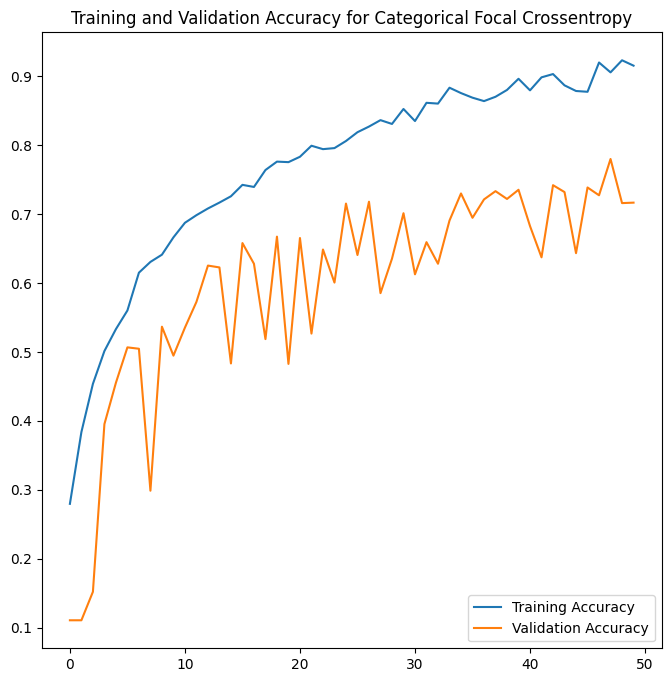

In [27]:
acc = history.history['accuracy'] 
val_acc = history.history['val_accuracy'] 
loss = history.history['loss'] 
val_loss = history.history['val_loss'] 
epochs_range = range(50) 
plt.figure(figsize=(8, 8)) 
# plt.subplot(1, 2, 1) 
plt.plot(epochs_range, acc, label='Training Accuracy') 
plt.plot(epochs_range, val_acc, label='Validation Accuracy') 
plt.legend(loc='lower right') 
plt.title('Training and Validation Accuracy for Categorical Focal Crossentropy') 